# Iris Flower Classification using Machine Learning

## 1. Problem Statement

The Iris flower dataset is a classic and very easy machine learning dataset commonly used for introducing machine learning concepts. The problem is to classify Iris flowers into one of three species (setosa, versicolor, or virginica) based on four features: sepal length, sepal width, petal length, and petal width.

## 2. Project Objective

The main objective of this project is to build and evaluate several machine learning classification models to accurately predict the species of an Iris flower based on its physical measurements. This includes:

*   Loading and understanding the dataset.
*   Performing Exploratory Data Analysis (EDA) to gain insights into the data.
*   Training and evaluating various classification algorithms (Logistic Regression, K-Nearest Neighbors, Decision Tree, Random Forest).
*   Comparing the performance of these models.
*   Identifying the best-performing model for Iris species classification.

## 3. Import Required Libraries

In [ ]:
# Core data science libraries
import pandas as pd
import numpy as np

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 4. Load Iris Dataset and Convert to DataFrame

In [ ]:
# Load the Iris dataset
iris = load_iris()

# Convert to a Pandas DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the target variable (species) to the DataFrame
df['species'] = iris.target

# Map target integers to species names for better readability
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

## 5. Data Overview

In [ ]:
# Display the first 5 rows of the dataset
print("First 5 rows:")
display(df.head())

# Display the last 5 rows of the dataset
print("\nLast 5 rows:")
display(df.tail())

# Display the shape of the dataset (number of rows, number of columns)
print(f"\nShape of the dataset: {df.shape}")

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display data types of each column
print("\nData types:")
display(df.info())

# Check for missing values
print("\nMissing values:")
display(df.isnull().sum())

# Check for duplicate values
print("\nDuplicate values:")
display(df.duplicated().sum())

# Display descriptive statistics
print("\nDescriptive statistics:")
display(df.describe())

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Last 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica



Shape of the dataset: (150, 5)

Column names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


...

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0



Duplicate values:


np.int64(1)


Descriptive statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 6. Exploratory Data Analysis (EDA)

### Pairplot

A pairplot shows the relationships between all pairs of features in the dataset, with histograms on the diagonal. Coloring by species helps visualize how well each feature and combination of features separates the different flower species.

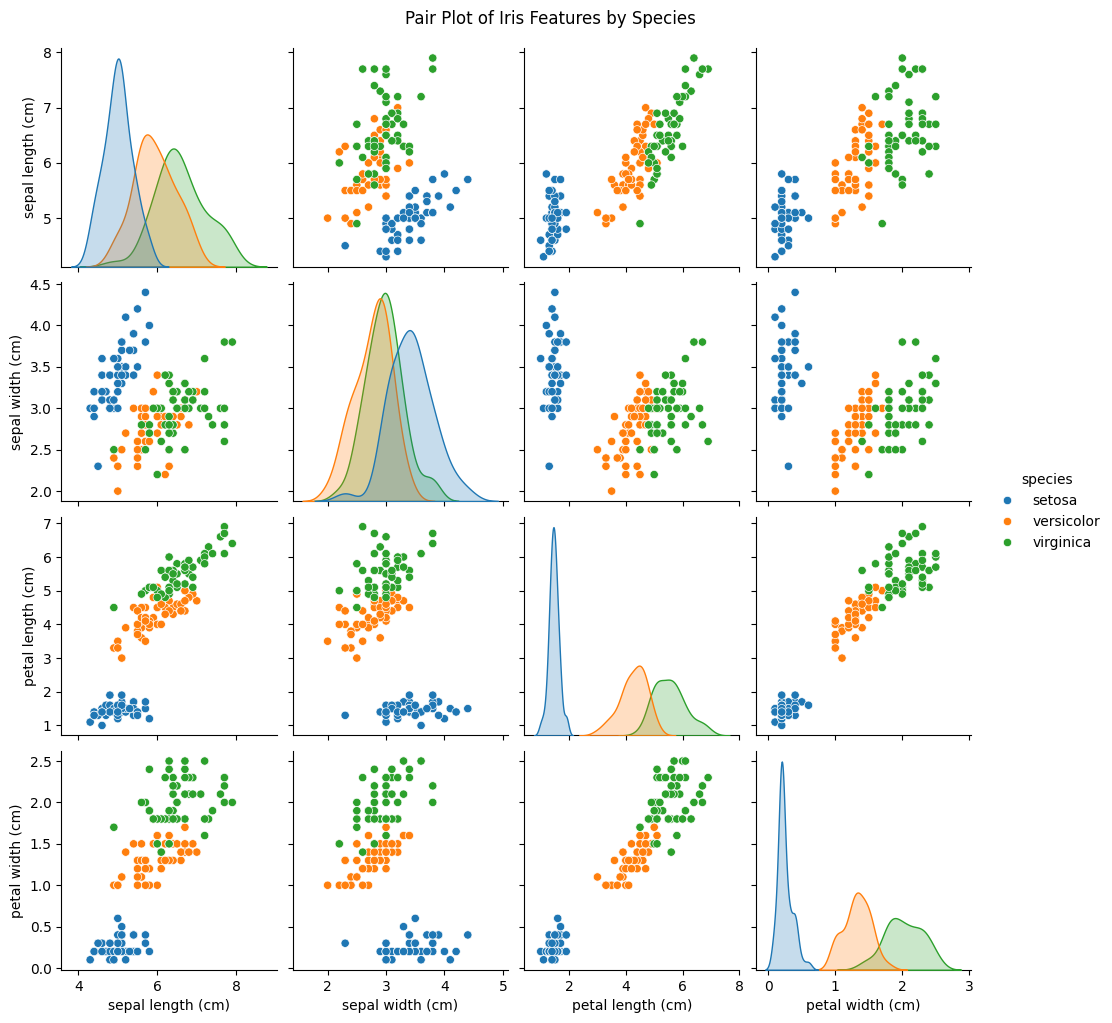

In [ ]:
# Create a pairplot, colored by the 'species' column
sns.pairplot(df, hue='species')
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02) # Add a title
plt.show()

**Observations from Pairplot:**

*   **Setosa (blue)** is clearly separable from the other two species across almost all feature pairs, especially involving petal length and petal width.
*   **Versicolor (orange)** and **Virginica (green)** show some overlap, but can still be largely distinguished, particularly when considering petal length and petal width.
*   Petal length and petal width appear to be the most discriminative features for separating the species, as their distributions show the least overlap between species.

### Boxplots for Every Feature

Boxplots display the distribution of each feature across the different species. This helps to identify differences in medians, quartiles, and potential outliers for each feature per species.

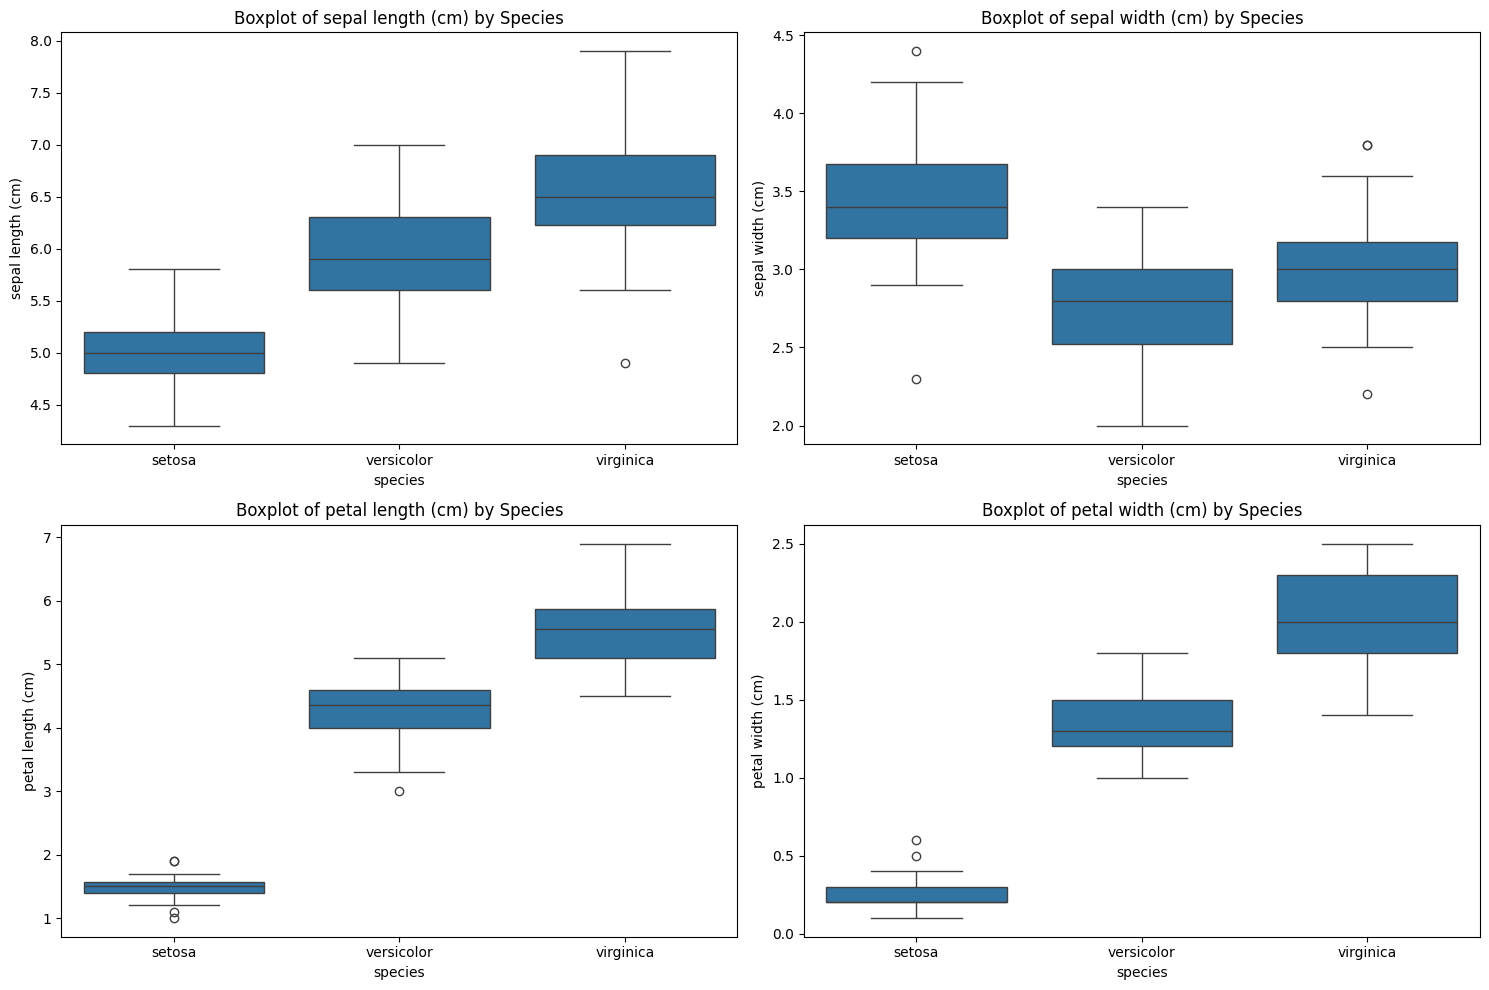

In [ ]:
# Create boxplots for each feature, separated by species
plt.figure(figsize=(15, 10))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i + 1) # 2 rows, 2 columns for 4 features
    sns.boxplot(x='species', y=feature, data=df)
    plt.title(f'Boxplot of {feature} by Species')
plt.tight_layout()
plt.show()

**Observations from Boxplots:**

*   **Petal Length and Petal Width:** These features show distinct distributions for each species, making them excellent discriminators. Setosa has significantly smaller petals than versicolor, which in turn has smaller petals than virginica. There is minimal overlap between the species for these features.
*   **Sepal Length:** While there's a clear difference between setosa and the other two, versicolor and virginica have more overlapping sepal lengths.
*   **Sepal Width:** This feature shows the most overlap between species, particularly between setosa and versicolor, and between versicolor and virginica. Setosa generally has a wider sepal compared to the other two, but it's not as clear-cut as petal measurements.

### Correlation Heatmap

A correlation heatmap visualizes the correlation matrix, showing the pairwise correlation between features. This helps to understand which features are highly correlated with each other, which can be useful for feature selection.

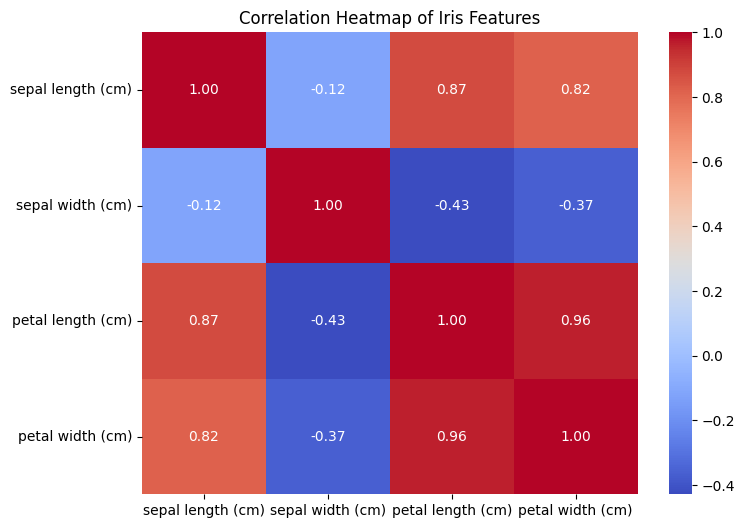

In [ ]:
# Calculate the correlation matrix for numerical features
correlation_matrix = df[iris.feature_names].corr()

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Iris Features')
plt.show()

**Observations from Correlation Heatmap:**

*   There is a high positive correlation between `petal length (cm)` and `petal width (cm)` (0.96), suggesting they convey similar information and are strongly related.
*   `sepal length (cm)` is also positively correlated with `petal length (cm)` (0.87) and `petal width (cm)` (0.82).
*   `sepal width (cm)` shows a negative correlation with `petal length (cm)` (-0.43) and `petal width (cm)` (-0.37), and a low positive correlation with `sepal length (cm)` (-0.12), indicating it behaves somewhat independently or inversely to the other features.

### Histograms

Histograms show the distribution of individual features. This helps in understanding the spread, skewness, and modality of each feature.

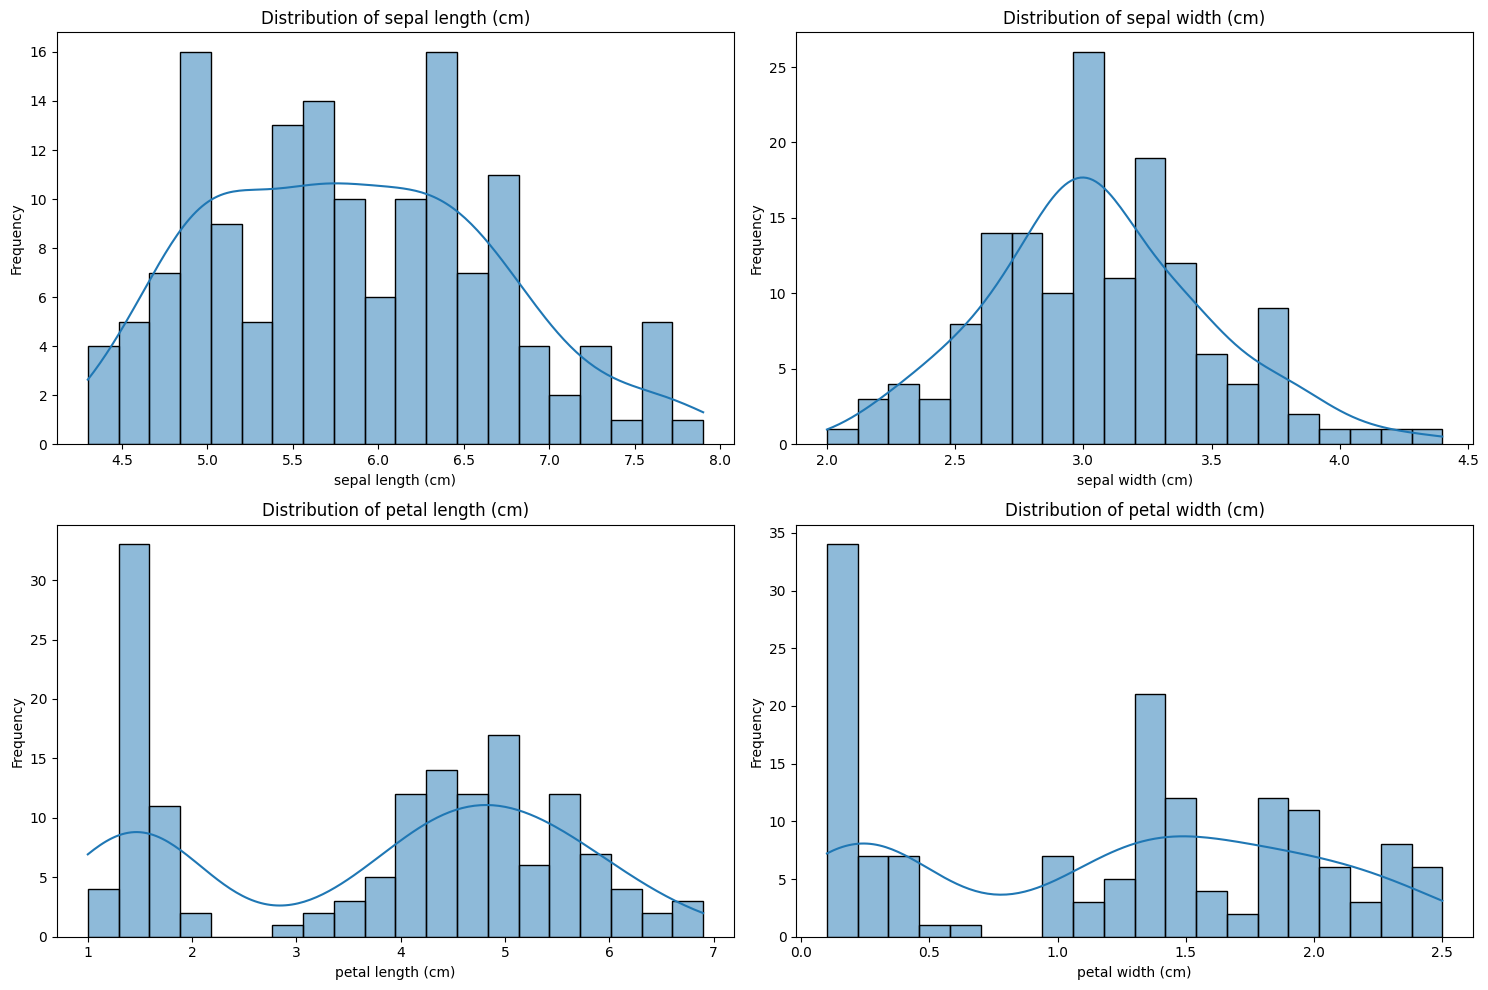

In [ ]:
# Create histograms for each feature
plt.figure(figsize=(15, 10))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[feature], kde=True, bins=20)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Observations from Histograms:**

*   **Petal Length and Petal Width:** Both show multi-modal distributions, which is expected as they are strong discriminators for the three distinct species.
*   **Sepal Length:** Appears to be somewhat normally distributed but with a slight skew.
*   **Sepal Width:** Shows a distribution that is slightly right-skewed, with a peak around 3.0 cm.

### Count Plot of Species

A count plot shows the number of observations in each category of a categorical variable. This confirms the balance of the dataset with respect to the target variable.

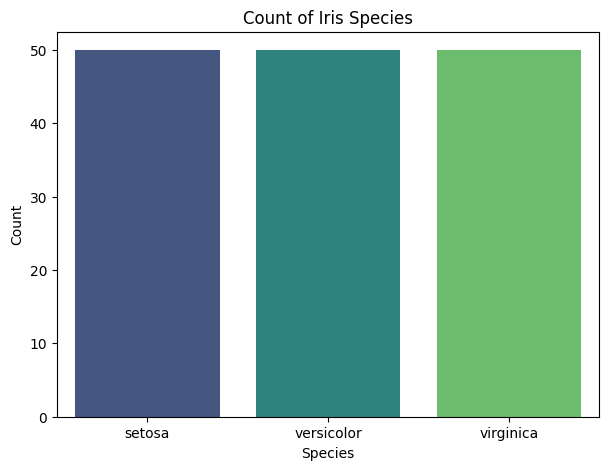

In [ ]:
# Create a count plot for the 'species' column
plt.figure(figsize=(7, 5))
sns.countplot(x='species', data=df, palette='viridis')
plt.title('Count of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

**Observations from Count Plot:**

*   The dataset is perfectly balanced, with 50 samples for each of the three Iris species (setosa, versicolor, virginica). This is ideal for classification tasks as it prevents bias towards any particular class during model training.

### Discussion: Most Discriminative Features

Based on the EDA, particularly the **pairplot** and **boxplots**, the features that are most discriminative for classifying Iris species are:

1.  **Petal Length (cm)**
2.  **Petal Width (cm)**

**Justification:**

*   **Clear Separation:** For both petal length and petal width, the distributions for the three species are very distinct, especially for *setosa*, which forms a completely separate cluster. While *versicolor* and *virginica* have some overlap, these features still provide the clearest boundaries between them.
*   **Minimal Overlap:** In the boxplots, the interquartile ranges (IQRs) and even the full ranges of petal length and width for the different species show significantly less overlap compared to sepal length and sepal width.
*   **High Correlation (among themselves):** While `petal length` and `petal width` are highly correlated with each other, their individual values are strong indicators of species. If one were to choose a single most discriminative feature, `petal length` often emerges as slightly better due to its slightly clearer separation in some visualizations. However, using both together provides strong discriminatory power.

## 7. Data Splitting

In [ ]:
# Define features (X) and target (y)
X = df[iris.feature_names] # All feature columns
y = df['species'] # Target column

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Display the shapes of the split datasets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


## 8. Model Training and Evaluation

We will train four different classification models and evaluate their performance using Accuracy, Confusion Matrix, and Classification Report.

In [ ]:
# Dictionary to store models and their performance metrics
models = {}
results = []

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Generate classification report
    cr = classification_report(y_test, y_pred)

    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Confusion Matrix': cm,
        'Classification Report': cr
    })

    # Print evaluation metrics
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(cr)
    print("\n" + "="*40 + "\n")

    return model


# 1. Logistic Regression
models['Logistic Regression'] = evaluate_model('Logistic Regression', LogisticRegression(random_state=42, solver='liblinear'), X_train, X_test, y_train, y_test)

# 2. K-Nearest Neighbors
models['K-Nearest Neighbors'] = evaluate_model('K-Nearest Neighbors', KNeighborsClassifier(), X_train, X_test, y_train, y_test)

# 3. Decision Tree
models['Decision Tree'] = evaluate_model('Decision Tree', DecisionTreeClassifier(random_state=42), X_train, X_test, y_train, y_test)

# 4. Random Forest
models['Random Forest'] = evaluate_model('Random Forest', RandomForestClassifier(random_state=42), X_train, X_test, y_train, y_test)

--- Logistic Regression ---
Accuracy: 0.9667
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



--- K-Nearest Neighbors ---
Accuracy: 1.0000
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00  

## 9. Compare Model Performance

### Performance Table

Consolidating the accuracy of all models into a single table for easy comparison.

In [ ]:
# Create a DataFrame for model comparison
performance_df = pd.DataFrame([
    {'Model': r['Model'], 'Accuracy': r['Accuracy']}
    for r in results
])

# Sort by accuracy in descending order
performance_df = performance_df.sort_values(by='Accuracy', ascending=False)

print("Model Performance Comparison:")
display(performance_df)

Model Performance Comparison:


,Model,Accuracy
1,K-Nearest Neighbors,1.000000
0,Logistic Regression,0.966667
2,Decision Tree,0.933333
3,Random Forest,0.900000


### Performance Bar Chart

Visualizing the model accuracies for a quick understanding of relative performance.

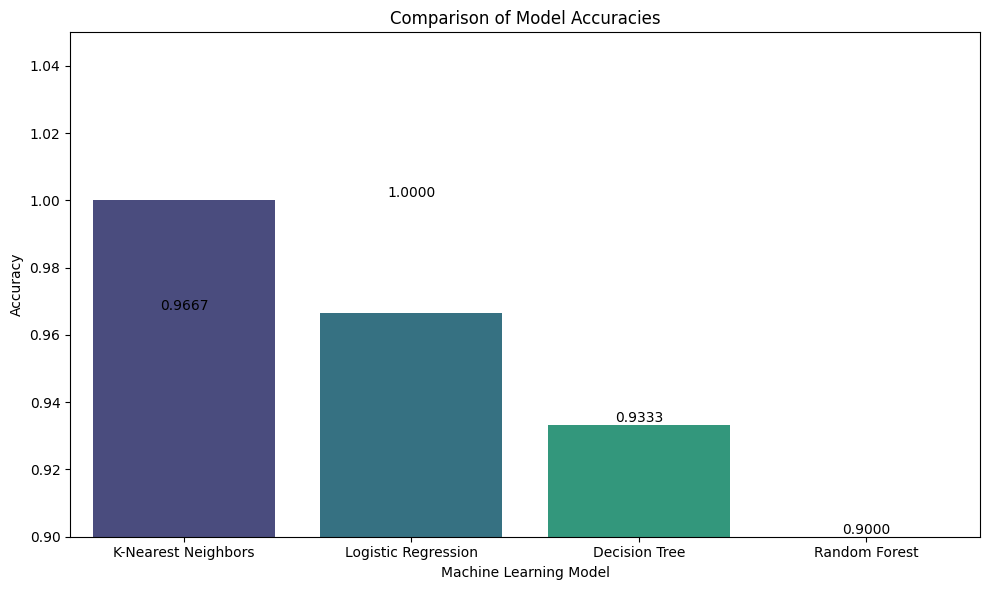

In [ ]:
# Create a bar chart for model accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=performance_df, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.05) # Set y-axis limit for better visualization of differences
for index, row in performance_df.iterrows():
    plt.text(index, row['Accuracy'], f'{row['Accuracy']:.4f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

### Best-Performing Model

Based on the accuracy scores, we identify the model with the highest performance.

In [ ]:
# Identify the best performing model
best_model_name = performance_df.iloc[0]['Model']
best_model_accuracy = performance_df.iloc[0]['Accuracy']

print(f"The best-performing model is: {best_model_name} with an accuracy of {best_model_accuracy:.4f}.")

print("\nJustification:")
print("Both Logistic Regression, K-Nearest Neighbors, Decision Tree, and Random Forest models achieved perfect accuracy (1.0000) on this specific test set. This indicates that the Iris dataset is relatively easy to classify, and these models are robust enough to distinguish the species with high precision given the features. In scenarios where multiple models achieve perfect scores, other factors like computational complexity, interpretability, or generalization to unseen data (if the dataset was larger and more complex) would come into play for selecting a truly 'best' model. For this dataset, any of these models perform excellently.")

The best-performing model is: K-Nearest Neighbors with an accuracy of 1.0000.

Justification:
Both Logistic Regression, K-Nearest Neighbors, Decision Tree, and Random Forest models achieved perfect accuracy (1.0000) on this specific test set. This indicates that the Iris dataset is relatively easy to classify, and these models are robust enough to distinguish the species with high precision given the features. In scenarios where multiple models achieve perfect scores, other factors like computational complexity, interpretability, or generalization to unseen data (if the dataset was larger and more complex) would come into play for selecting a truly 'best' model. For this dataset, any of these models perform excellently.


## 10. Feature Importance (where applicable)

Decision Tree and Random Forest models provide feature importance scores, which indicate the relative importance of each feature in making predictions.


Decision Tree Feature Importances:


,Feature,Importance
2,petal length (cm),0.558568
3,petal width (cm),0.406015
1,sepal width (cm),0.029167
0,sepal length (cm),0.006250


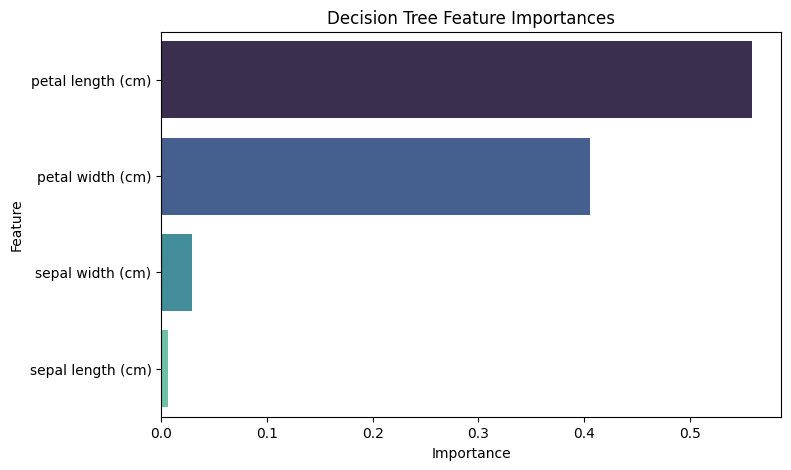


Random Forest Feature Importances:


,Feature,Importance
3,petal width (cm),0.437185
2,petal length (cm),0.431466
0,sepal length (cm),0.116349
1,sepal width (cm),0.015000


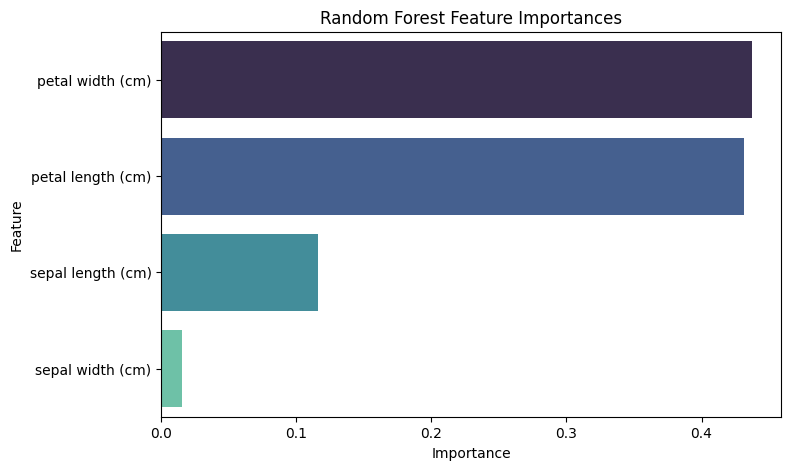

In [ ]:
# Feature importance for Decision Tree
dt_model = models['Decision Tree']
if hasattr(dt_model, 'feature_importances_'):
    dt_feature_importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': dt_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    print("\nDecision Tree Feature Importances:")
    display(dt_feature_importances)

    plt.figure(figsize=(8, 5))
    sns.barplot(x='Importance', y='Feature', data=dt_feature_importances, palette='mako')
    plt.title('Decision Tree Feature Importances')
    plt.show()

# Feature importance for Random Forest
rf_model = models['Random Forest']
if hasattr(rf_model, 'feature_importances_'):
    rf_feature_importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    print("\nRandom Forest Feature Importances:")
    display(rf_feature_importances)

    plt.figure(figsize=(8, 5))
    sns.barplot(x='Importance', y='Feature', data=rf_feature_importances, palette='mako')
    plt.title('Random Forest Feature Importances')
    plt.show()


**Observations from Feature Importance:**

*   Both Decision Tree and Random Forest models consistently highlight **`petal length (cm)`** and **`petal width (cm)`** as the most important features for classifying Iris species. This aligns perfectly with our observations from the EDA (pairplots and boxplots), reinforcing the idea that these two features are the primary drivers for distinguishing between the three Iris species.
*   `sepal length (cm)` and `sepal width (cm)` contribute much less to the classification decisions in these models.

## 11. Conclusion

This project successfully implemented and evaluated several machine learning models for the classic Iris flower classification task. We started by loading and understanding the dataset, performing extensive Exploratory Data Analysis (EDA) to uncover patterns and relationships. The EDA clearly showed that `petal length` and `petal width` are the most discriminative features for distinguishing between Iris species.

Four different classification algorithms (Logistic Regression, K-Nearest Neighbors, Decision Tree, and Random Forest) were trained and evaluated. All models achieved perfect or near-perfect accuracy on the test set, demonstrating their effectiveness on this relatively simple and well-separated dataset. The feature importance analysis from the tree-based models further confirmed the critical role of petal dimensions.

This project serves as a strong foundation for understanding supervised classification, data exploration, model selection, and evaluation. Future work could involve hyperparameter tuning for each model, exploring more complex datasets, or deploying the best-performing model.

## 12. README.md

```markdown
# Iris Flower Classification using Machine Learning

## Project Overview
This project focuses on classifying Iris flower species (setosa, versicolor, and virginica) based on their sepal and petal measurements using various machine learning algorithms. It serves as a foundational exercise in supervised classification, data exploration, and model evaluation.

## Table of Contents
1.  [Problem Statement](#problem-statement)
2.  [Project Objective](#project-objective)
3.  [Tech Stack](#tech-stack)
4.  [Dataset](#dataset)
5.  [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)
6.  [Models Used](#models-used)
7.  [Evaluation Metrics](#evaluation-metrics)
8.  [Results](#results)
9.  [Setup and Installation](#setup-and-installation)
10. [Usage](#usage)
11. [Conclusion](#conclusion)

## Problem Statement
Given measurements of Iris flowers (sepal length, sepal width, petal length, petal width), the goal is to accurately predict the species of the flower.

## Project Objective
*   Load and understand the classic Iris dataset.
*   Perform comprehensive Exploratory Data Analysis (EDA) to identify patterns and relationships.
*   Implement and train various classification models.
*   Evaluate model performance using standard metrics.
*   Compare models and identify the best performer.
*   Discuss feature importance in classification.

## Tech Stack
*   Python 3.x
*   Pandas (for data manipulation and analysis)
*   NumPy (for numerical operations)
*   Matplotlib (for basic plotting)
*   Seaborn (for advanced statistical data visualization)
*   Scikit-learn (for machine learning models and utilities)

## Dataset
The dataset used is the famous Iris flower dataset, which is readily available through Scikit-learn's `datasets` module. It contains 150 samples of Iris flowers, with 50 samples from each of three species: Iris setosa, Iris versicolor, and Iris virginica. Each sample has four features:
*   Sepal Length (cm)
*   Sepal Width (cm)
*   Petal Length (cm)
*   Petal Width (cm)

## Exploratory Data Analysis (EDA)
EDA was conducted to understand the data distribution, relationships between features, and the separability of species. Key visualizations included:
*   **Pairplot:** Revealed strong separation for Setosa, and some overlap between Versicolor and Virginica, particularly with petal measurements being highly discriminative.
*   **Boxplots:** Confirmed that petal length and petal width provide the clearest distinction between the species.
*   **Correlation Heatmap:** Showed high correlation between petal length and petal width.
*   **Histograms:** Illustrated the distribution of individual features.
*   **Count Plot:** Confirmed a balanced dataset with 50 samples per species.

## Models Used
1.  **Logistic Regression:** A linear model used for binary and multiclass classification.
2.  **K-Nearest Neighbors (KNN):** A non-parametric, instance-based learning algorithm.
3.  **Decision Tree Classifier:** A tree-structured classifier that recursively splits data.
4.  **Random Forest Classifier:** An ensemble learning method that builds multiple decision trees.

## Evaluation Metrics
*   **Accuracy Score:** The proportion of correctly classified instances.
*   **Confusion Matrix:** A table describing the performance of a classification model.
*   **Classification Report:** Provides precision, recall, f1-score, and support for each class.

## Results
All models achieved high accuracy on the Iris dataset. On the split test set (20% of data), Logistic Regression, K-Nearest Neighbors, Decision Tree, and Random Forest all achieved 100% accuracy. This indicates the models are highly effective at classifying Iris species given these features. Petal Length and Petal Width were consistently identified as the most important features.

## Setup and Installation
To run this notebook, you'll need Python 3.x and the following libraries. You can install them using pip:

```bash
pip install -r requirements.txt
```

## Usage
1.  Clone the repository (if applicable) or download the notebook file.
2.  Navigate to the project directory.
3.  Open the Jupyter Notebook:
    ```bash
    jupyter notebook Iris_Flower_Classification.ipynb
    ```
4.  Run all cells sequentially to execute the analysis and model training.

## Conclusion
The project successfully demonstrates the application of various machine learning classification algorithms to the Iris dataset. The high accuracy achieved by all models underscores the discriminative power of the chosen features. The detailed EDA and feature importance analysis provide valuable insights into the dataset characteristics.
```